Unser Ziel ist es, die Art der Pinguine vorherzusagen. Dabei liegt der Schwerpunkt ganz klar auf einer transparenten und gut nachvollziehbaren Modellierung. Die Interpretierbarkeit hat also Vorrang vor reiner Vorhersageleistung. Machine Learning setzen wir nur dann ein, wenn klassische, leicht nachvollziehbare statistische Verfahren an ihre Grenzen stoßen.

In [49]:
import pandas as pd
from utils import show_missing_values, num_corr_heatmap, cat_corr_heatmap, cramers_v_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import missingno as msno
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text
import graphviz

In [50]:
plt.style.use("fivethirtyeight")
pd.set_option('display.max_columns', 100)
RANDOM_SEED = 42

In [ ]:
def plot_confusion_matrix(cm, classes):
    """
    Erstellt eine Konfusionsmatrix.
    """
    sns.heatmap(cm, annot=True, xticklabels=classes, yticklabels=classes, cmap='Oranges', fmt='d')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

def dt_graph(model):
    """
    Erstellt eine Visualisierung des Entscheidungsbaums.
    """
    dot_data = export_graphviz(
        model.named_steps['clf'],
        out_file=None,
        feature_names=model.named_steps['prep'].get_feature_names_out(),
        class_names=model.named_steps['clf'].classes_,
        filled=True,
        rounded=True,
        special_characters=True
    )
    
    graph = graphviz.Source(dot_data)
    return graph

In [52]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [53]:
show_missing_values(df)

,Column Name,Min,Max,n Unique,NaN count,NaN percentage,dtype
S. No.,,,,,,,
1,species,nan,nan,3,0,0.0%,object
2,island,nan,nan,3,0,0.0%,object
3,bill_length_mm,32.1,59.6,164,2,0.581%,float64
4,bill_depth_mm,13.1,21.5,80,2,0.581%,float64
5,flipper_length_mm,172.0,231.0,55,2,0.581%,float64
6,body_mass_g,2700.0,6300.0,94,2,0.581%,float64
7,sex,nan,nan,2,11,3.198%,object


Wir sehen es gibt für alle 4 Messungen 2 Werte fehlen, wahr. sind die alle für die gleichen Datenpunkten fehlen?
Außerdem fehlen 11 Werte für Geschlecht.

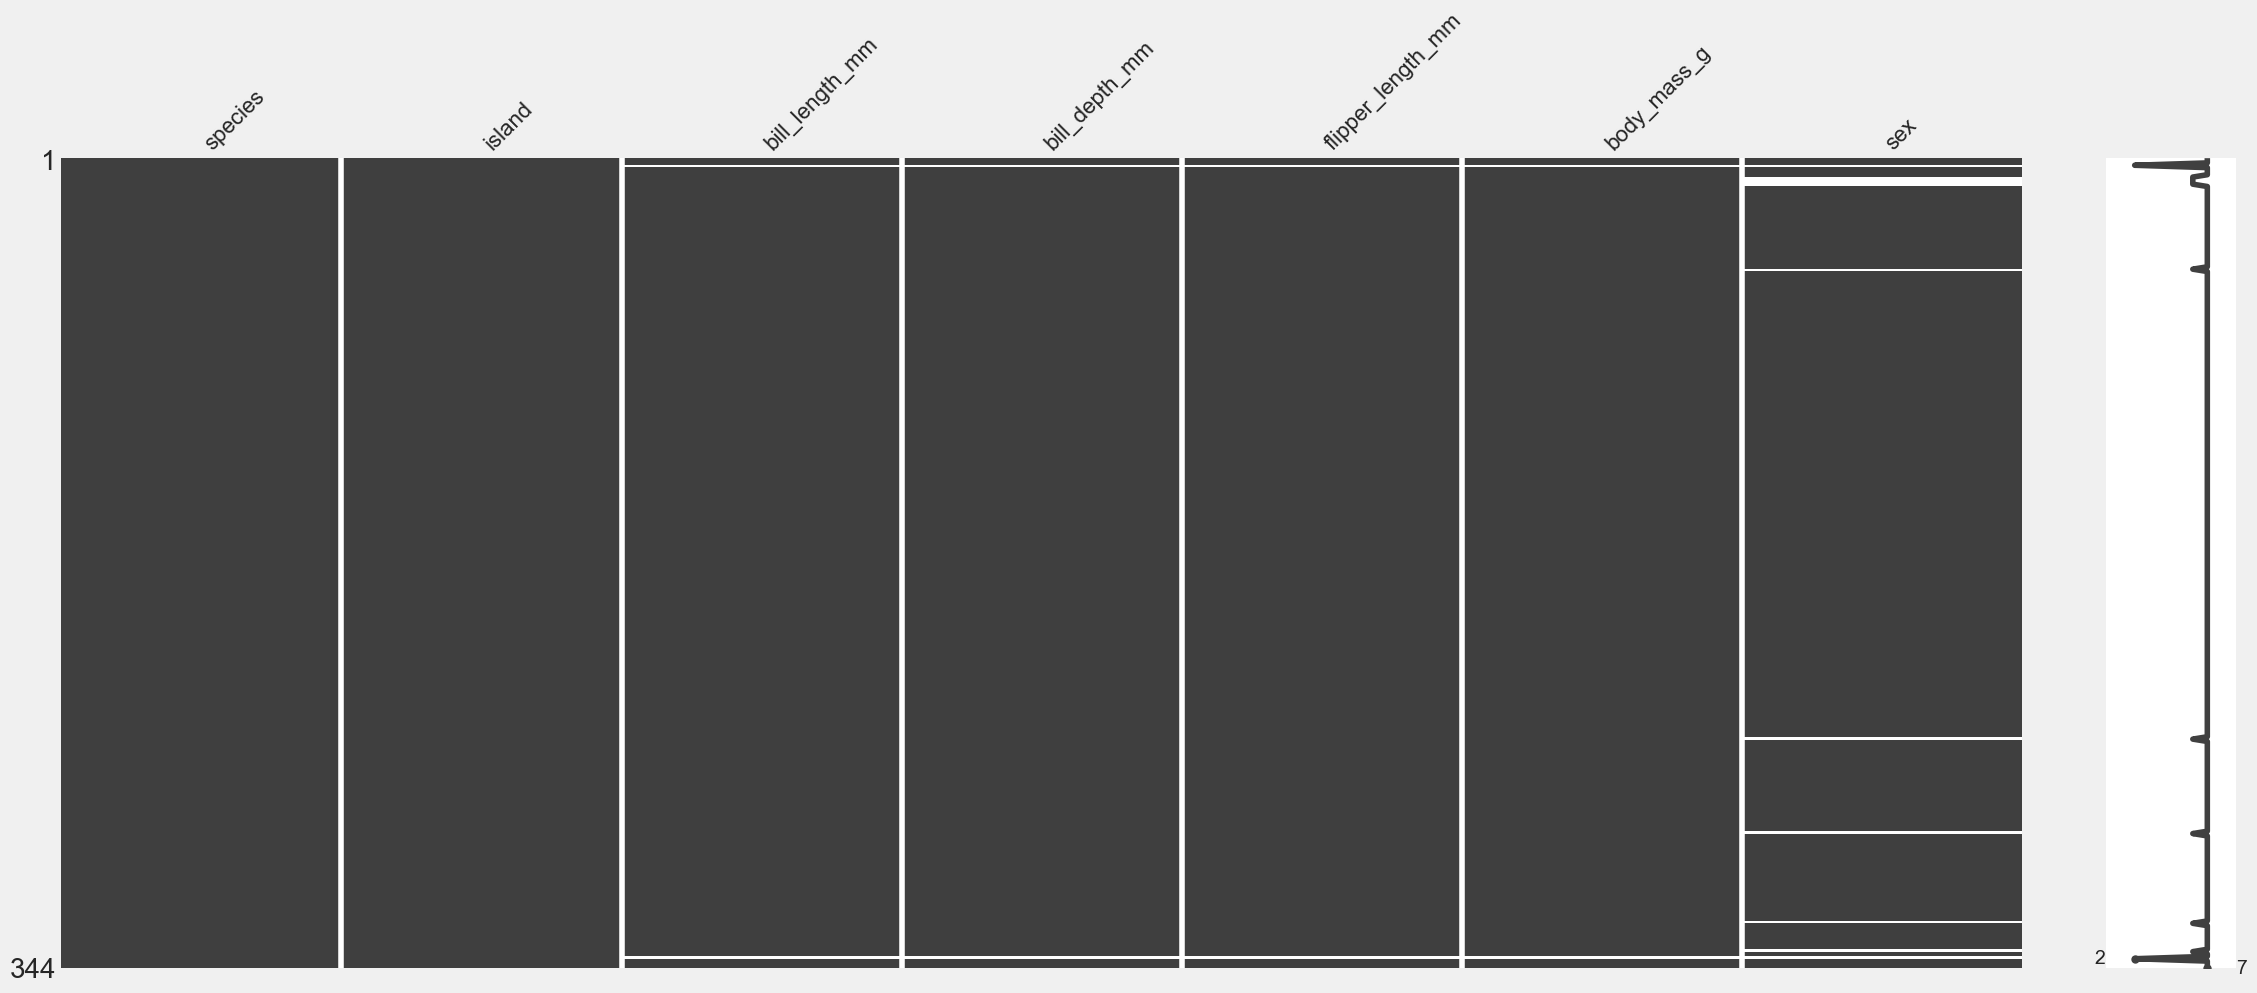

In [54]:
msno.matrix(df);

Man sieht in der MSNO Matrix, dass bei denselben zwei Datenpunkten nicht nur alle vier numerischen Messungen fehlen, sondern auch das Geschlecht. Daher würde ich diese Datenpunkte einfach droppen.

In der Produktion könnte man das über eine *Fallback-Logik* abfangen: Fehlen alle Hauptfeatures, gibt das Modell direkt die *Majoritätsklasse* zurück, in unserem Fall `Adelie`, was immerhin bei 44.15% der Fälle korrekt wäre. Dadurch vermeiden wir, dass durch irgendeine Imputierung potenziell unrealistische Werte ins Modell gelangen.

Hinweis:
Alternativ könnte man versuchen, anhand der Insel die bedingte Wahrscheinlichkeit für die Art zu schätzen oder im Preprocessing einen *KNNImputer* einsetzen, um fehlende Werte durch einigermaßen "realistische" Werte zu ersetzen. Da es sich aber nur um zwei Datenpunkte handelt (rund 0.58 % des Datensatzes), lohnt sich dieser Aufwand praktisch nicht.

In [93]:
df.species.value_counts(normalize=True)

species
Adelie       0.441520
Gentoo       0.359649
Chinstrap    0.198830
Name: proportion, dtype: float64

In [55]:
df = df.dropna(subset=['bill_length_mm'])
show_missing_values(df)

,Column Name,Min,Max,n Unique,NaN count,NaN percentage,dtype
S. No.,,,,,,,
1,species,nan,nan,3,0,0.0%,object
2,island,nan,nan,3,0,0.0%,object
3,bill_length_mm,32.1,59.6,164,0,0.0%,float64
4,bill_depth_mm,13.1,21.5,80,0,0.0%,float64
5,flipper_length_mm,172.0,231.0,55,0,0.0%,float64
6,body_mass_g,2700.0,6300.0,94,0,0.0%,float64
7,sex,nan,nan,2,9,2.632%,object


Jetzt fehlen nur noch Geschlecht Werte von 9 Datenpunkten, um die kümmern wir uns später.

# EDA

Wir versuchen zunächst komplett manuell (visuell) die Klassen zu trennen und schauen ob wir überhaupt ML brauchen werden (Wir gehen davon aus dass wir nicht brauchen) 

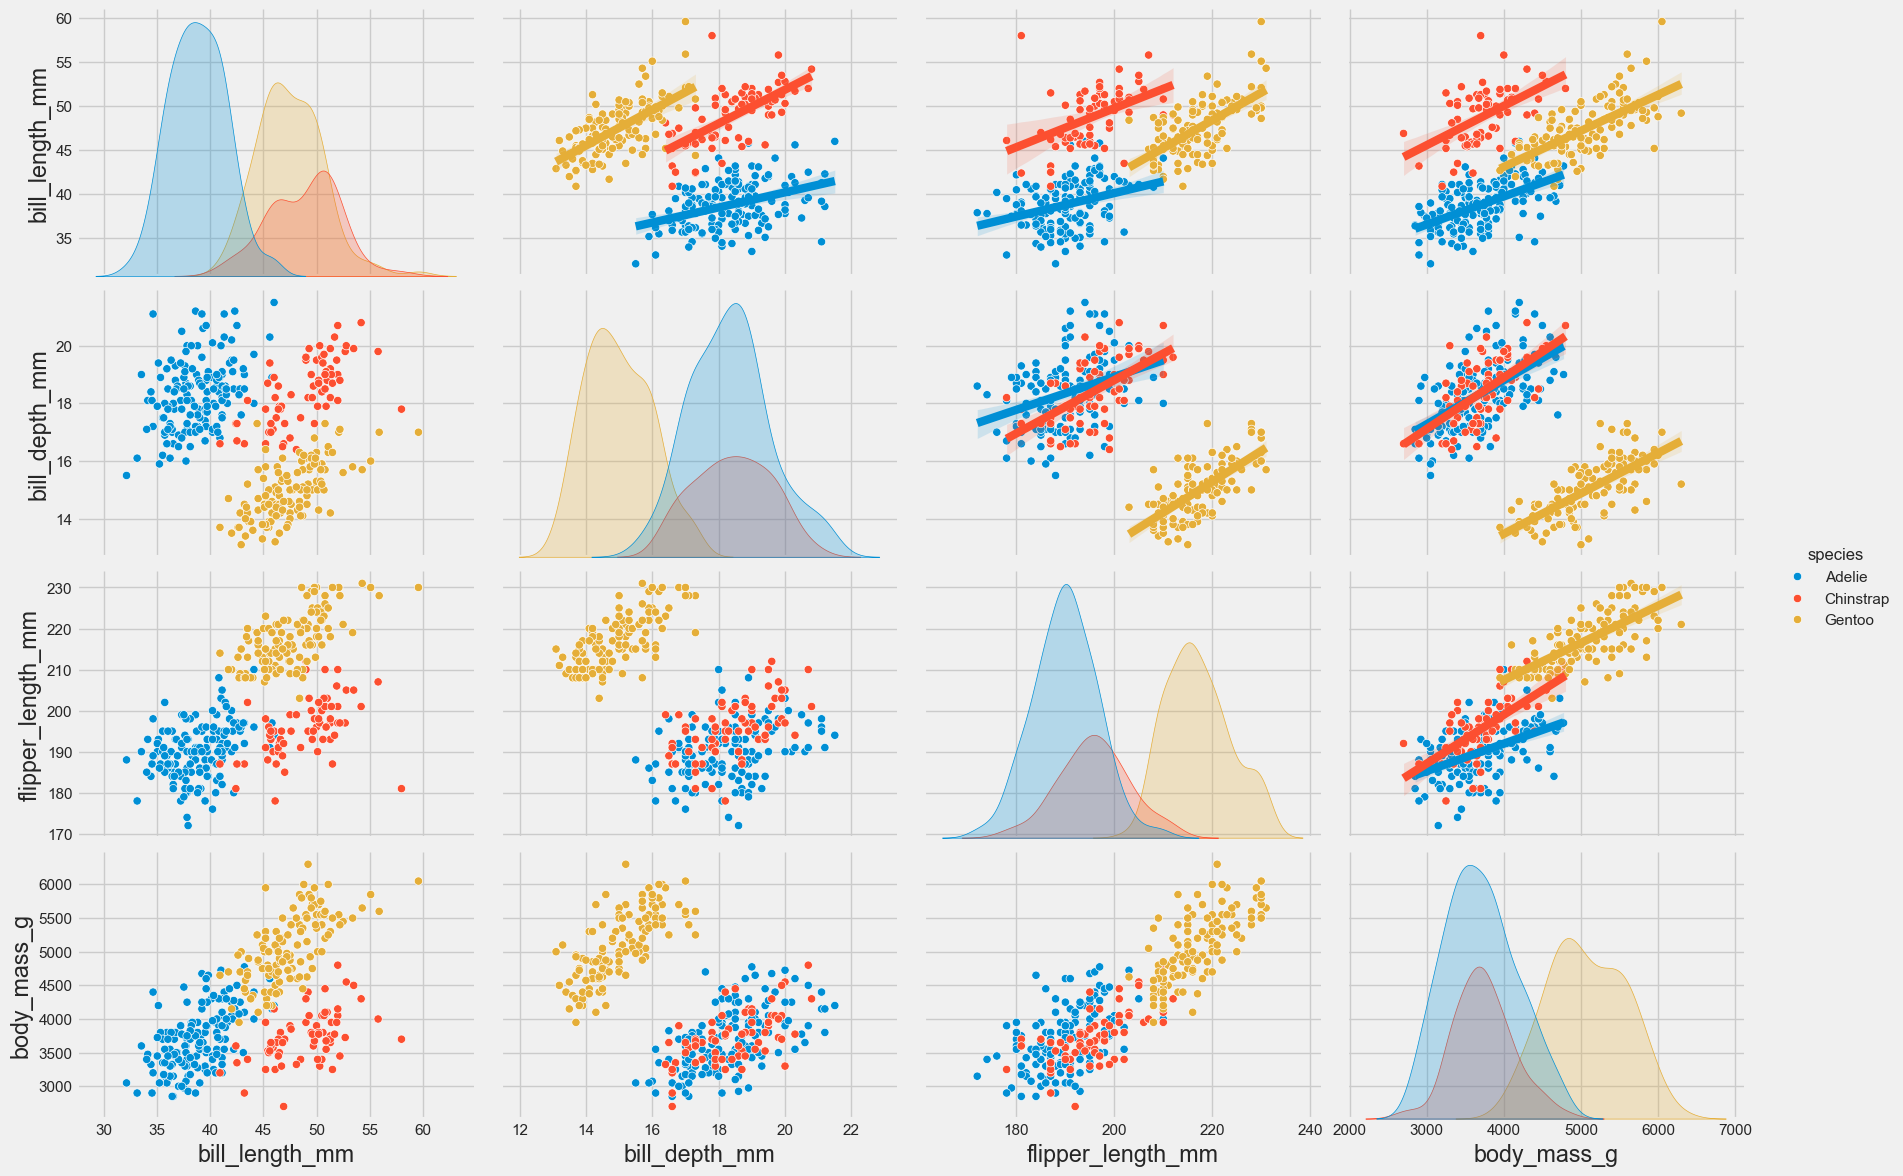

In [56]:
g = sns.pairplot(df, hue='species', diag_kind='kde', height=3, aspect=1.5);
g.map_upper(sns.regplot, scatter=False);

Wir sehen, dass `bill_length_mm` allein schon eine ziemlich gute Trennung zwischen allen drei Arten ermöglicht. Bei den anderen Merkmalen, in denen keine `bill_length_mm` vorkommt, lässt sich zwar die Art `Gentoo` weiterhin gut unterscheiden, aber `Adelie` und `Chinstrap` überlappen stark.

Aus dieser Grafik können wir daher bereits vermuten, dass `bill_length_mm` ein besonders wichtiges Feature sein wird. Was wir an dieser Stelle jedoch noch nicht wissen, ist, mit welchen weiteren Merkmalen (`body_mass_g`, `flipper_length_mm`, `bill_depth_mm`) sich `bill_length_mm` am sinnvollsten kombinieren lässt, um eine möglichst robuste und generalisierbare Trennschärfe zu erreichen.  

Auch die kategorialen Variablen `sex` und `island` haben wir in dieser Darstellung noch nicht berücksichtigt.

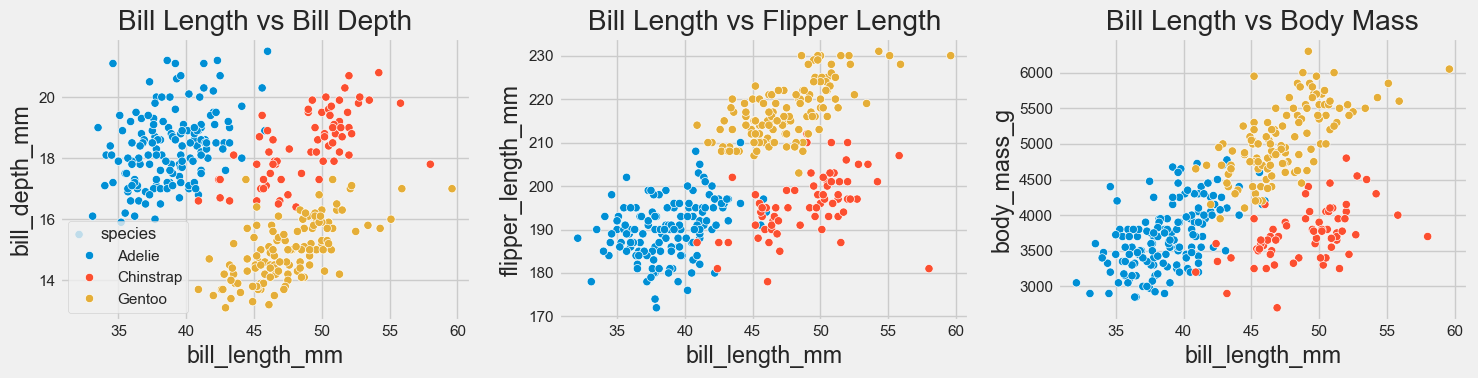

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species', ax=axes[0]);
axes[0].set_title('Bill Length vs Bill Depth');
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm', hue='species', ax=axes[1]);
axes[1].set_title('Bill Length vs Flipper Length');
axes[1].legend_.remove();
sns.scatterplot(data=df, x='bill_length_mm', y='body_mass_g', hue='species', ax=axes[2]);
axes[2].set_title('Bill Length vs Body Mass');
axes[2].legend_.remove();
plt.tight_layout();
plt.show()

`bill_length_mm` hier nochmal genauer angeschaut.

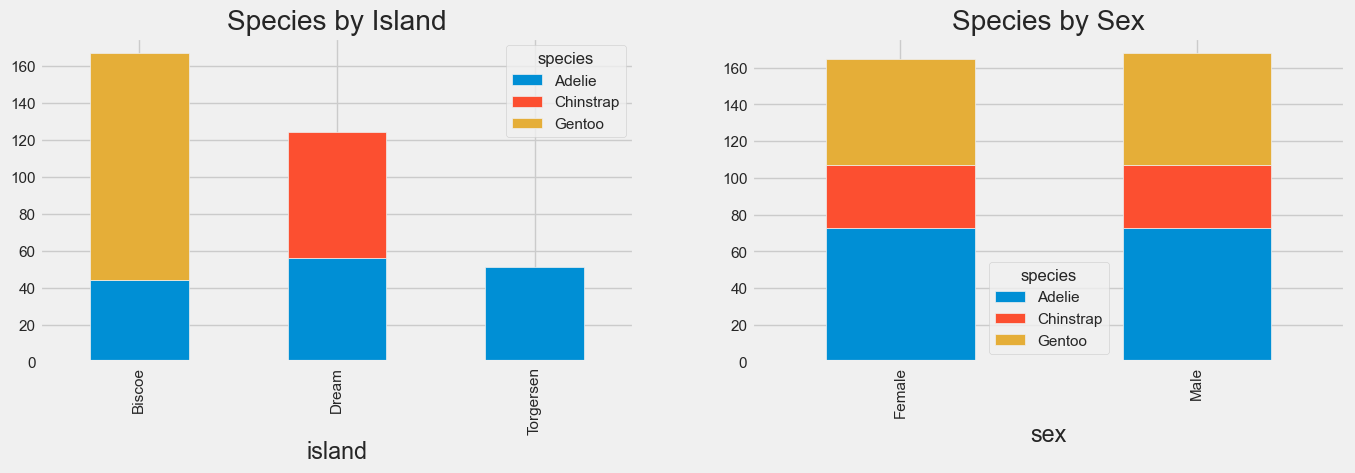

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
pd.crosstab(df.island, df.species).plot.bar(stacked=True, ax=axes[0]);
axes[0].set_title('Species by Island');
pd.crosstab(df.sex, df.species).plot.bar(stacked=True, ax=axes[1]);
axes[1].set_title('Species by Sex');

**Grafik links**  
Bisher fehlte uns ein Überblick über die kategorialen Features `island` und `sex`.  
In der linken Grafik sieht man bereits einige interessante Muster für `island`:

- Auf der Insel `biscoe` kommt *keine* `Adelie` vor  
  →  $\text{Biscoe} \Rightarrow \neg \text{Adelie}$
- Auf der Insel `dream` kommt *keine* `Gentoo` vor  
  →  $\text{Dream} \Rightarrow \neg \text{Gentoo}$
- Auf der Insel `torgersen` findet man *nur* `Adelie`  
  →  $\text{Torgersen} \Rightarrow \text{Adelie}$

**Wichtig:**  
Hier darf man keinen logischen Umkehrschluss ziehen.
Die Aussagen oben heißen *nicht*, dass man aus der Insel auf die Art schließen könnte:

- `Adelie` kommt auf **allen** Inseln vor, also kann man sie nicht anhand der Insel vorhersagen.  
- `Chinstrap` und `Gentoo` treten zwar jeweils nur auf einer Insel auf, aber dort gibt es **auch** `Adelie`.  

Man kann also auch sie nicht eindeutig bestimmen.

Kurz gesagt: Nur wenn `island = torgersen`, wissen wir sicher, dass die Art `Adelie` ist. 
Dabei ist zu beachten, dass wir natürlich die Vorhersage *von* `island` *auf* `species` betrachten und nicht andersrum.

Hochstens ist diese Variable sehr nutzlich aussieht aber wir wissen noch nicht wie sie sich zusammen mit den anderen Variablen verhält.

**Grafik rechts**  
Bei der Variable `sex` fällt auf, dass die Verteilungen für alle Arten **exakt gleich** sind. Jede Art hat **genau** dieselbe Anzahl an männlichen und weiblichen Individuen.   Das bedeutet, dass `sex` **vollständig unabhängig** von der Art ist und somit **keine Information** zur Vorhersage von `species` enthält.

$$ \Rightarrow P(\text{species} | \text{sex}) = P(\text{species})$$

`sex` ist wahr. daher eine *Kontrollvariable*. D.h. sie wurde so erhoben, dass in allen Gruppen die Geschlechterverteilung konstant bleibt. Aber Achtung nur weil die Variable Wir behalten sie also vorerst im Datensatz.

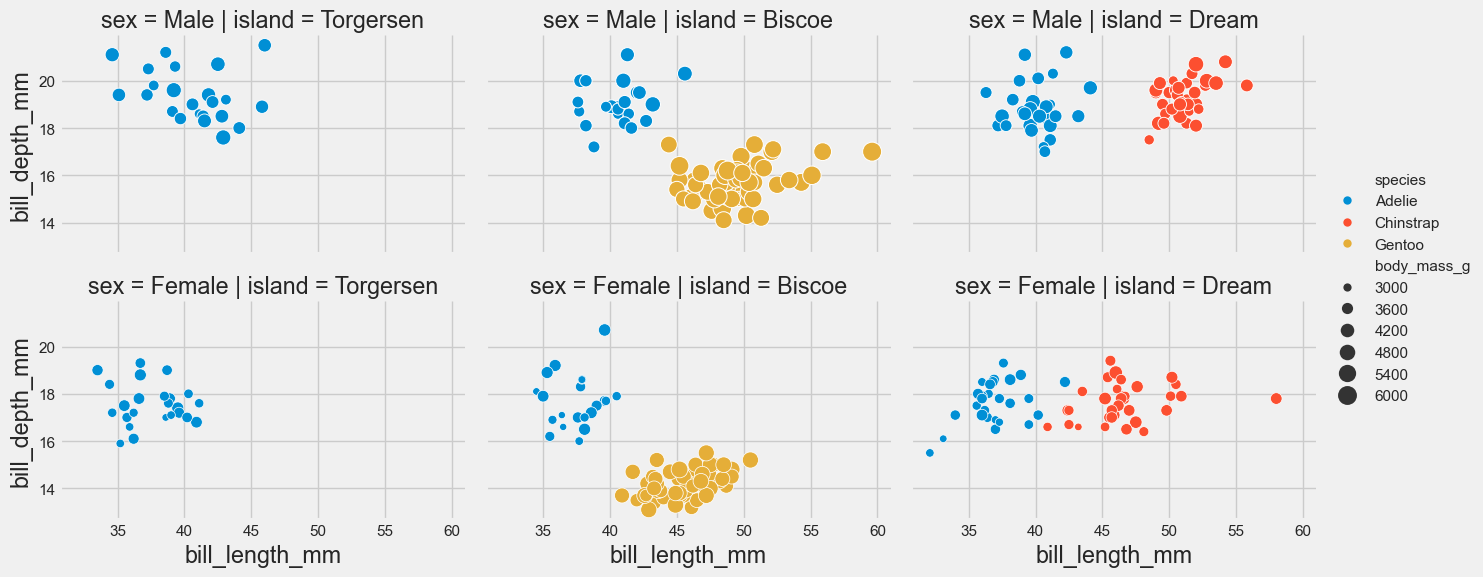

In [59]:
sns.relplot(x='bill_length_mm', 
            y='bill_depth_mm', 
            data=df, 
            hue='species', 
            col='island', 
            height=3, 
            aspect=1.5, 
            size='body_mass_g',
            row='sex',
            sizes=(20, 200));

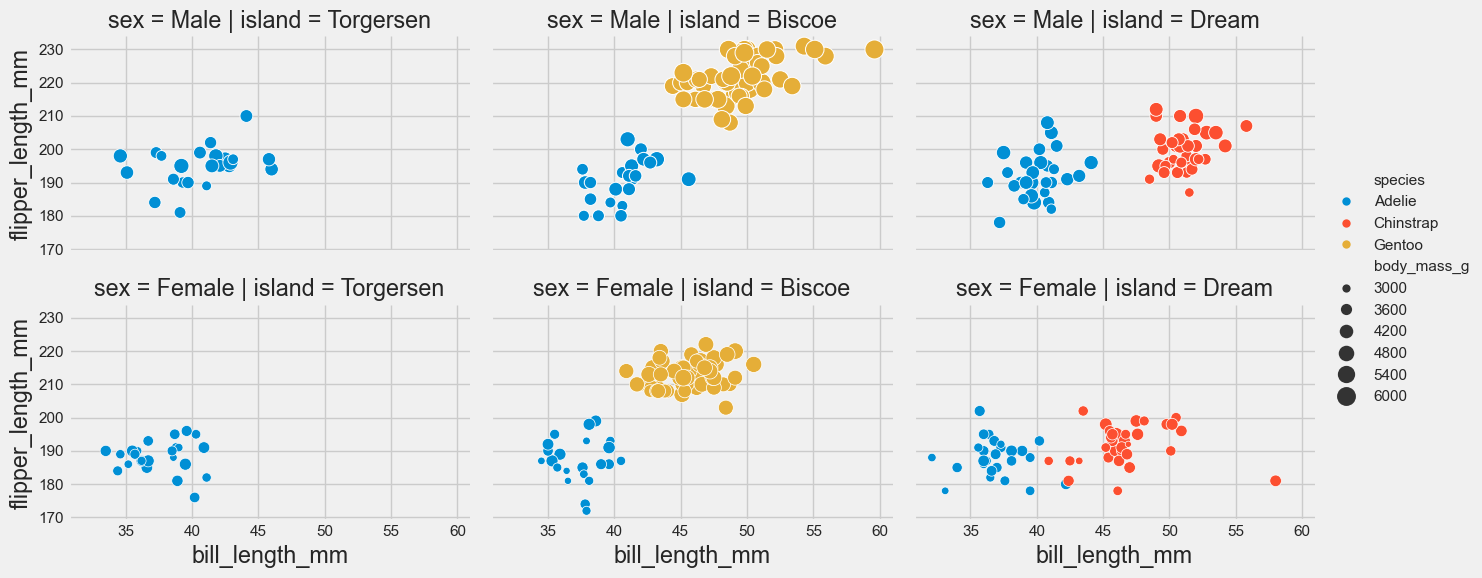

In [60]:
sns.relplot(x='bill_length_mm', 
            y='flipper_length_mm', 
            data=df, 
            hue='species', 
            col='island', 
            height=3, 
            aspect=1.5, 
            size='body_mass_g',
            row='sex',
            sizes=(20, 200));

In [61]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='bill_length_mm',
    y='bill_depth_mm',
    z='flipper_length_mm',
    color='species',
    size='body_mass_g'
)
fig.show()

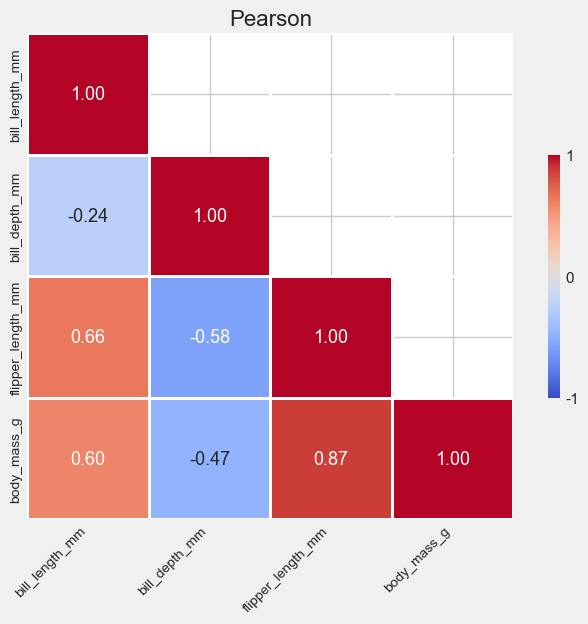

In [62]:
num_corr_heatmap(df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr())

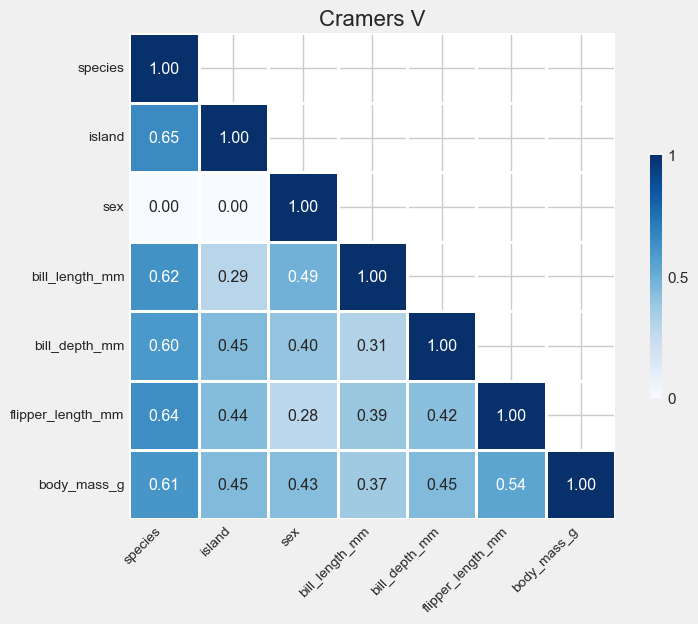

In [63]:
cramers_v = cramers_v_matrix(df)
cat_corr_heatmap(cramers_v);

In [64]:
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']
df['body_prop'] = df['flipper_length_mm'] / df['body_mass_g']

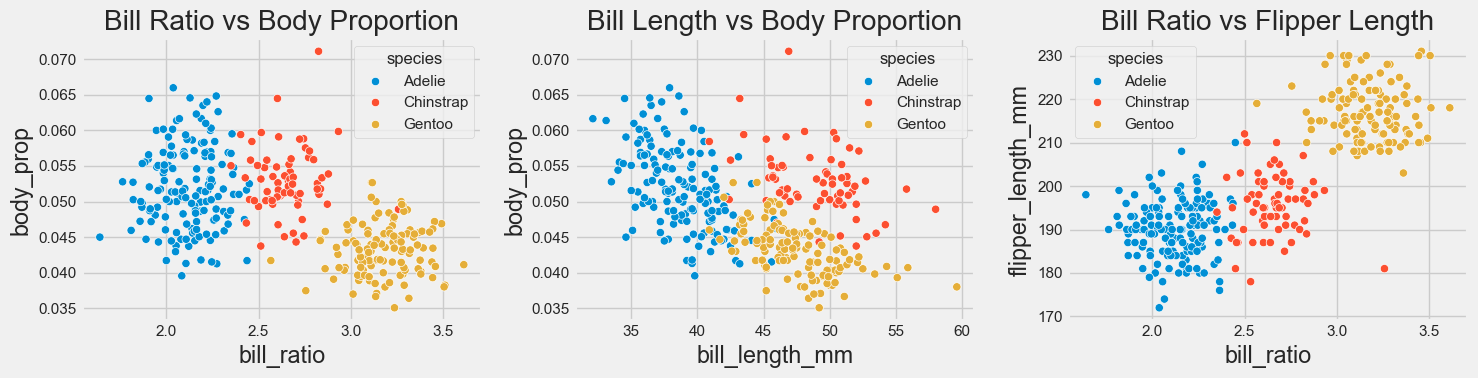

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(
    data=df,
    x='bill_ratio',
    y='body_prop',
    hue='species',
    ax=axes[0]
)
axes[0].set_title('Bill Ratio vs Body Proportion');
sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='body_prop',
    hue='species',
    ax=axes[1]
)
axes[1].set_title('Bill Length vs Body Proportion');
sns.scatterplot(
    data=df,
    x='bill_ratio',
    y='flipper_length_mm',
    hue='species',
    ax=axes[2]
)
axes[2].set_title('Bill Ratio vs Flipper Length');
plt.tight_layout();
plt.show()

In [66]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio,body_prop
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,2.090909,0.048267
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,2.270115,0.048947
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,2.238889,0.060000
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1.901554,0.055942
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1.907767,0.052055


In [67]:
X = df[['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'bill_ratio', 'body_prop']]
y = df['species']
X_train_80, X_test, y_train_80, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

In [68]:
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'sex']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='error', sparse_output=False))
])

pseudo_transformer = FunctionTransformer(lambda x: x, feature_names_out='one-to-one')

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('pseudo', pseudo_transformer, [])
    ],
    verbose_feature_names_out=False
).set_output(transform='pandas')

model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', KNeighborsClassifier(n_neighbors=3))
])

In [69]:
X_train, X_val, y_train, y_val = train_test_split(X_train_80, y_train_80, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train_80)

model.fit(X_train, y_train)
y_pred = model.predict(X_val)
    
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [70]:
def stratified_cv_scores(model, X, y, cv=5, random_state=RANDOM_SEED):
    cv = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    cv_precision = cross_val_score(model, X, y, cv=cv, scoring='precision_macro').mean()
    cv_recall = cross_val_score(model, X, y, cv=cv, scoring='recall_macro').mean()
    cv_f1 = cross_val_score(model, X, y, cv=cv, scoring='f1_macro').mean()
    cv_accuracy = cross_val_score(model, X, y, cv=cv, scoring='accuracy').mean()
    return dict(precision=cv_precision, recall=cv_recall, f1=cv_f1, accuracy=cv_accuracy)

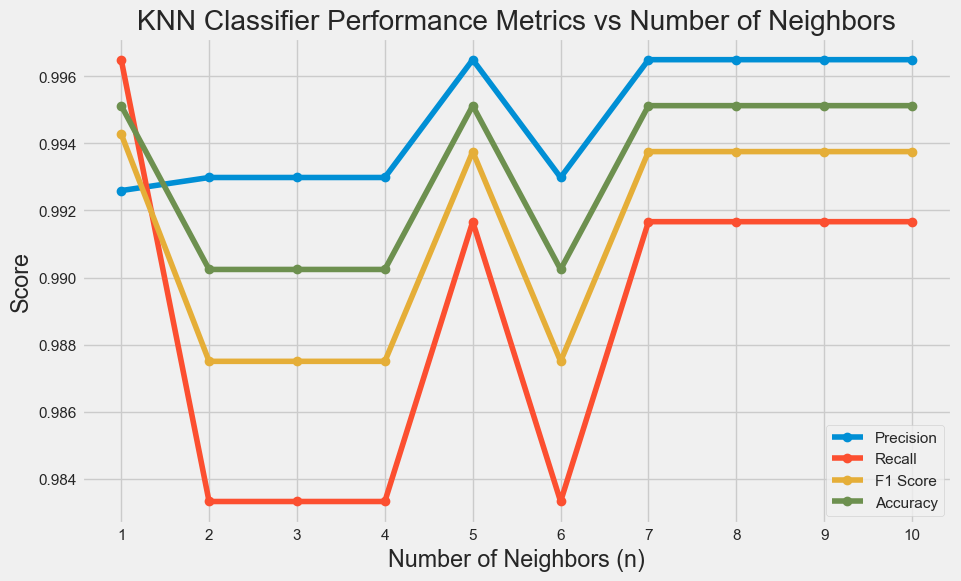

In [71]:
n_values = range(1, 11)
precision_scores = []
recall_scores = []
f1_scores = []
accuracy_scores = []

for n in n_values:
    model.set_params(clf__n_neighbors=n)
    cv_scores = stratified_cv_scores(model, X_train, y_train)
    precision_scores.append(cv_scores['precision'])
    recall_scores.append(cv_scores['recall'])
    f1_scores.append(cv_scores['f1'])
    accuracy_scores.append(cv_scores['accuracy'])

plt.figure(figsize=(10, 6))
plt.plot(n_values, precision_scores, label='Precision', marker='o')
plt.plot(n_values, recall_scores, label='Recall', marker='o')
plt.plot(n_values, f1_scores, label='F1 Score', marker='o')
plt.plot(n_values, accuracy_scores, label='Accuracy', marker='o')
plt.xlabel('Number of Neighbors (n)')
plt.ylabel('Score')
plt.title('KNN Classifier Performance Metrics vs Number of Neighbors')
plt.xticks(n_values)
plt.legend()
plt.show()

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



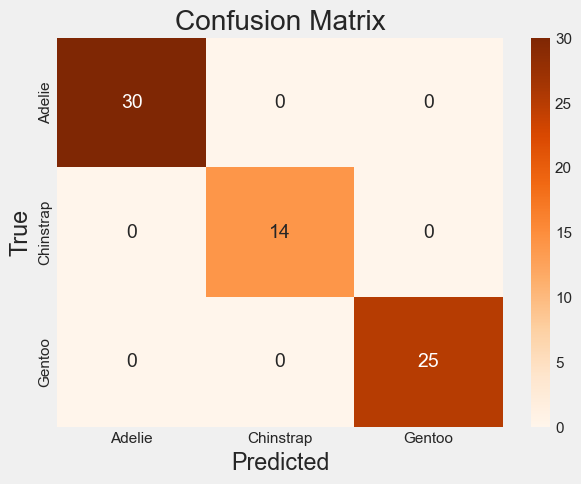

In [72]:
model.set_params(clf__n_neighbors=7)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))
classes = model.named_steps['clf'].classes_
cm = confusion_matrix(y_val, y_pred, labels=classes)
plot_confusion_matrix(cm, classes)
plt.show()

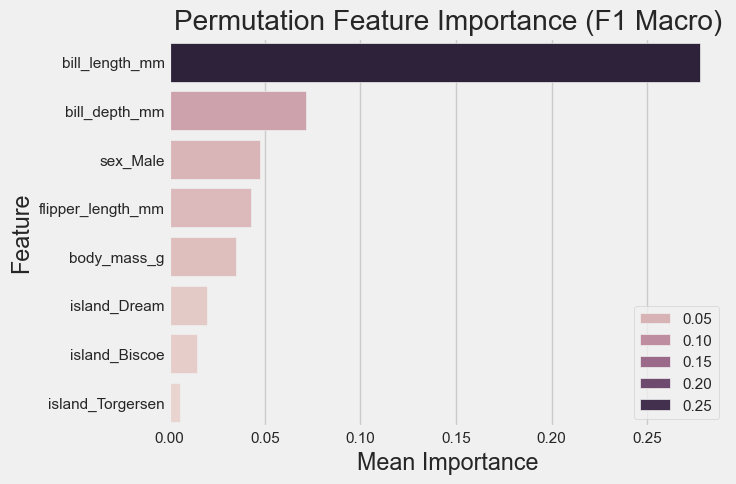

In [73]:
prep = model.named_steps['prep']
knn = model.named_steps['clf']
X_val_transformed = prep.transform(X_val)
result = permutation_importance(knn, X_val_transformed, y_val, n_repeats=30, random_state=RANDOM_SEED, n_jobs=-1, scoring='f1_macro')
feature_importances = pd.Series(result.importances_mean, index=prep.get_feature_names_out()).sort_values(ascending=False)
sns.barplot(x=feature_importances.values, y=feature_importances.index, hue=feature_importances.values)
plt.title('Permutation Feature Importance (F1 Macro)')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

{'precision': 0.9895384615384616, 'recall': 0.9745454545454546, 'f1': 0.9808556311413454, 'accuracy': 0.9852525252525253}


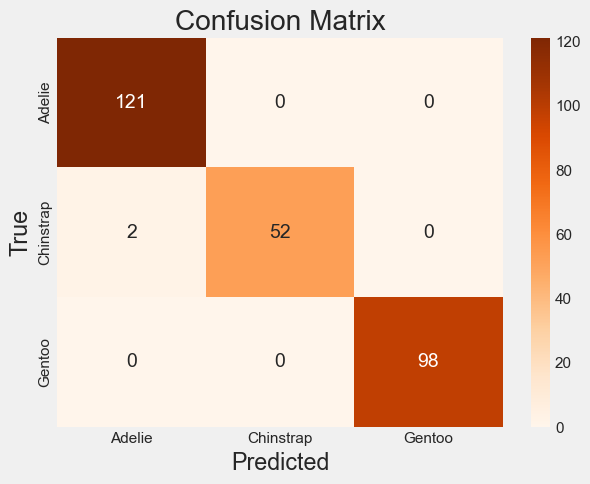

In [74]:
numerical_features = ['bill_length_mm', 'bill_depth_mm']
categorical_features = ['sex']

model.set_params(prep__transformers=
    [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)
cv_scores = stratified_cv_scores(model, X_train_80, y_train_80)
print(cv_scores)
model.fit(X_train_80, y_train_80)
classes = model.named_steps['clf'].classes_
y_pred = model.predict(X_train_80)
cm = confusion_matrix(y_train_80, y_pred, labels=classes)
plot_confusion_matrix(cm, classes)
plt.show()

### Decision Tree Classifier

In [75]:
clf = DecisionTreeClassifier(
    random_state=RANDOM_SEED,
    criterion='entropy',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None
)

categorical_features = ['island', 'sex']
numerical_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
model.set_params(
    clf=clf,
    prep__transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [76]:
cv_scores = stratified_cv_scores(model, X_train_80, y_train_80)
print(f"Decision Tree Classifier CV Scores:")
print(f"F1 Macro: {cv_scores['f1']:.4f}")
print(f"Recall Macro: {cv_scores['recall']:.4f}")
print(f"Precision Macro: {cv_scores['precision']:.4f}")
print(f"Accuracy: {cv_scores['accuracy']:.4f}")

Decision Tree Classifier CV Scores:
F1 Macro: 0.9512
Recall Macro: 0.9524
Precision Macro: 0.9548
Accuracy: 0.9560


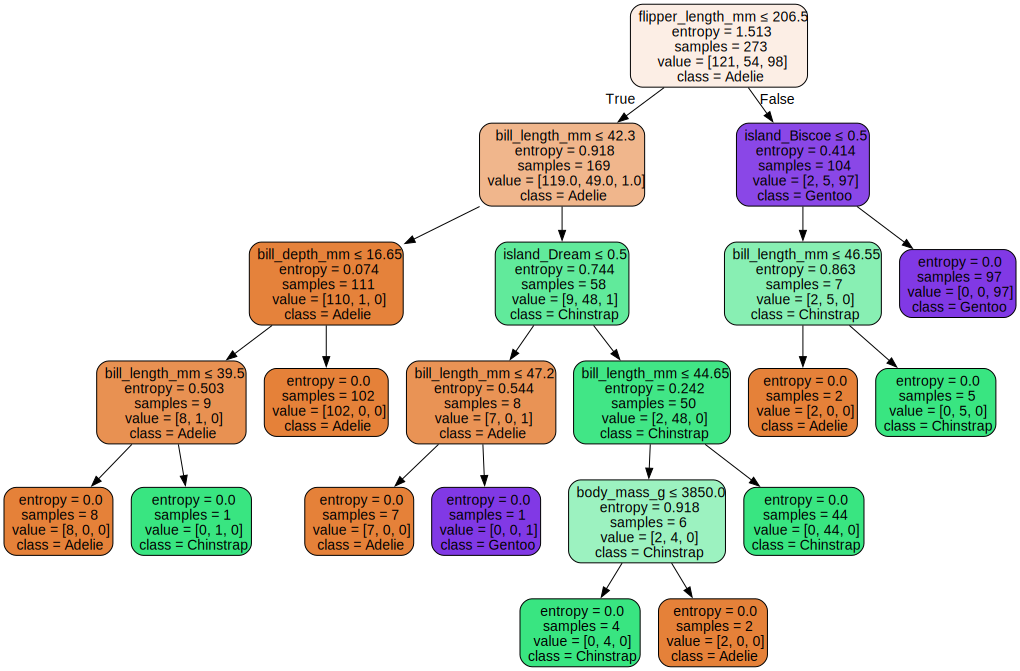

In [77]:
model.fit(X_train_80, y_train_80)
dt_graph(model)

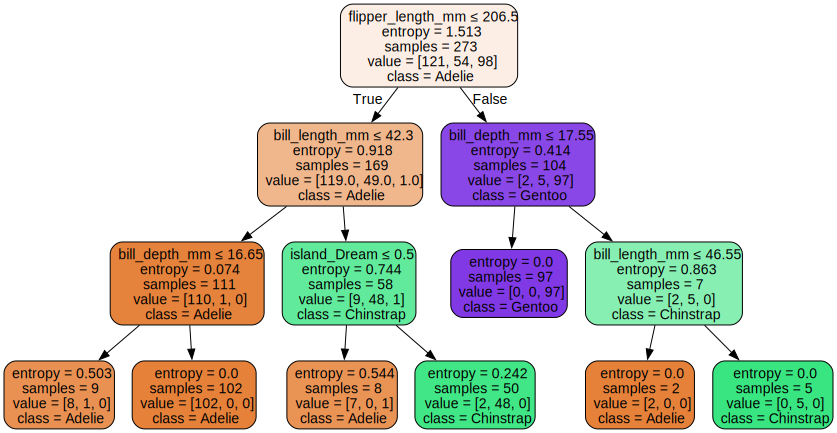

In [78]:
model.set_params(clf__max_depth=3)
model.fit(X_train_80, y_train_80)
dt_graph(model)

- flipper_length_mm > 206.5 & bill_depth_mm <= 17.55 -> Gentoo
- (flipper_length_mm > 206.5 & bill_depth_mm > 17.55 & bill_length_mm > 46.55) OR (flipper_length_mm <= 206.5 & bill_length_mm > 43.35 & island=="Dream") -> Chinstrap
- (flipper_length_mm > 206.5 & bill_depth_mm > 17.55 & bill_length_mm <= 46.55) OR (flipper_length_mm <= 206.5 & bill_length_mm <= 43.35) OR (flipper_length_mm <= 206.5 & bill_length_mm > 43.35 & island!="Dream") -> Adelie

In [79]:
cv_scores = stratified_cv_scores(model, X_train_80, y_train_80)
print(f"Decision Tree Classifier CV Scores:")
print(f"F1 Macro: {cv_scores['f1']:.4f}")
print(f"Recall Macro: {cv_scores['recall']:.4f}")
print(f"Precision Macro: {cv_scores['precision']:.4f}")
print(f"Accuracy: {cv_scores['accuracy']:.4f}")

Decision Tree Classifier CV Scores:
F1 Macro: 0.9559
Recall Macro: 0.9539
Precision Macro: 0.9625
Accuracy: 0.9597


              precision    recall  f1-score   support

      Adelie       0.98      0.98      0.98       121
   Chinstrap       0.96      0.98      0.97        54
      Gentoo       1.00      0.99      0.99        98

    accuracy                           0.99       273
   macro avg       0.98      0.98      0.98       273
weighted avg       0.99      0.99      0.99       273



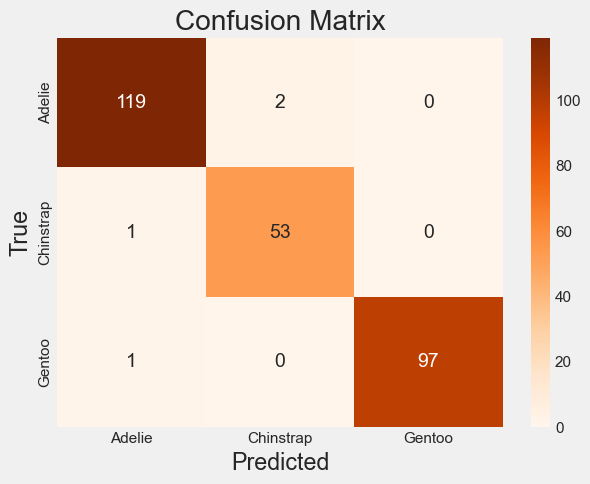

In [80]:
y_pred = model.predict(X_train_80)
print(classification_report(y_train_80, y_pred))
classes = model.named_steps['clf'].classes_
cm = confusion_matrix(y_train_80, y_pred, labels=classes)

plot_confusion_matrix(cm, classes)
plt.show()

In [81]:
tree_rules = export_text(model.named_steps["clf"],
                         feature_names=model.named_steps["prep"].get_feature_names_out())
print(tree_rules)

|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 42.30
|   |   |--- bill_depth_mm <= 16.65
|   |   |   |--- class: Adelie
|   |   |--- bill_depth_mm >  16.65
|   |   |   |--- class: Adelie
|   |--- bill_length_mm >  42.30
|   |   |--- island_Dream <= 0.50
|   |   |   |--- class: Adelie
|   |   |--- island_Dream >  0.50
|   |   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_depth_mm <= 17.55
|   |   |--- class: Gentoo
|   |--- bill_depth_mm >  17.55
|   |   |--- bill_length_mm <= 46.55
|   |   |   |--- class: Adelie
|   |   |--- bill_length_mm >  46.55
|   |   |   |--- class: Chinstrap



              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



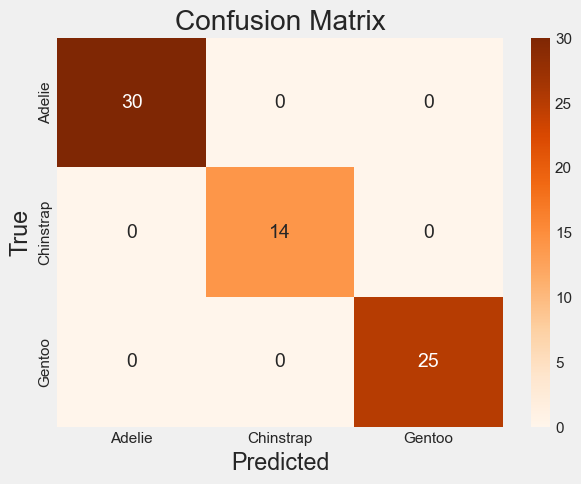

In [82]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
classes = model.named_steps['clf'].classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)

plot_confusion_matrix(cm, classes)
plt.show()

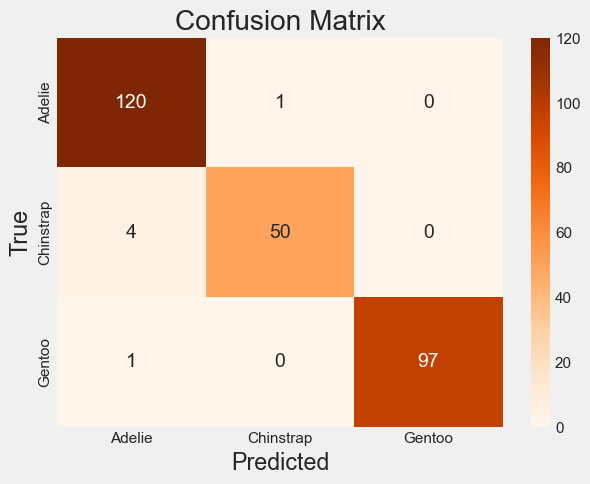

In [83]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5 and row.bill_depth_mm <= 17.55:
        return "Gentoo"
    elif ((row.flipper_length_mm <= 206.5 and row.bill_length_mm > 43.35 and row.island == "Dream")
          or (row.flipper_length_mm > 206.5 and row.bill_depth_mm > 17.55 and row.bill_length_mm > 46.55)):
        return "Chinstrap"
    else:
        return "Adelie"

y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

plot_confusion_matrix(cm, labels)
plt.show()

              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97       121
   Chinstrap       0.91      0.93      0.92        54
      Gentoo       1.00      0.99      0.99        98

    accuracy                           0.97       273
   macro avg       0.96      0.96      0.96       273
weighted avg       0.97      0.97      0.97       273



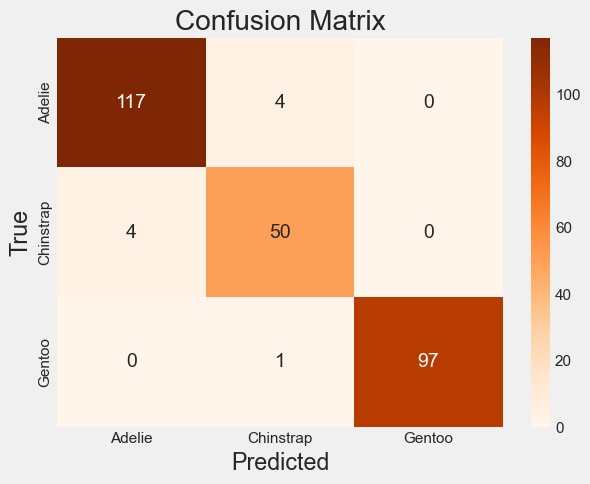

In [84]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5 and row.bill_depth_mm <= 17.55:
        return "Gentoo"
    elif ((row.flipper_length_mm <= 206.5 and row.bill_length_mm > 43.35)
          or (row.flipper_length_mm > 206.5 and row.bill_depth_mm > 17.55 and row.bill_length_mm > 46.55)):
        return "Chinstrap"
    else:
        return "Adelie"
    
y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

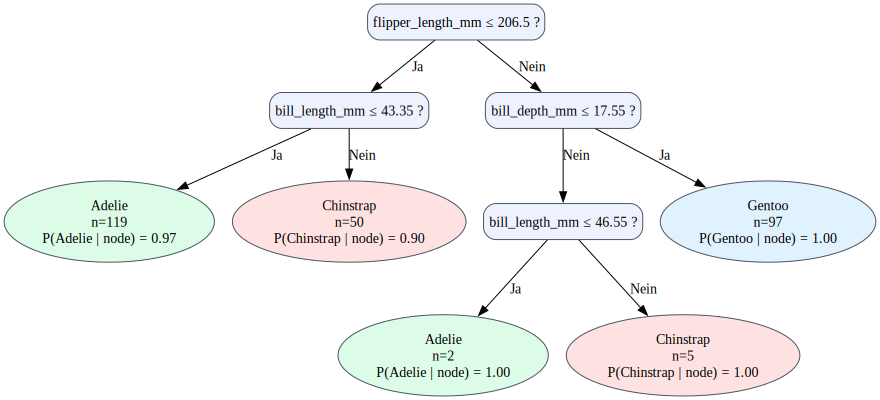

In [ ]:
# Quelle: bib.bib\citep{chatgpt_manual_rules_tree}

def rule_masks(df):
    left = df['flipper_length_mm'] <= 206.5
    right = ~left

    L_yes = left & (df['bill_length_mm'] <= 43.35)               # Adelie
    L_no  = left & (df['bill_length_mm'] > 43.35)                # Chinstrap

    R_yes = right & (df['bill_depth_mm'] <= 17.55)               # Gentoo
    R_no  = right & (df['bill_depth_mm'] > 17.55)
    R_no_yes = R_no & (df['bill_length_mm'] <= 46.55)            # Adelie
    R_no_no  = R_no & (df['bill_length_mm'] > 46.55)             # Chinstrap

    return {
        'L1_yes': L_yes, 'L1_no': L_no,
        'R1_yes': R_yes, 'R2_yes': R_no_yes, 'R2_no': R_no_no
    }

def label_with_stats(name, mask, y, cls_label, color):
    n = int(mask.sum())
    if n == 0:
        return f'{cls_label}\n(n=0)'
    dist = y[mask].value_counts(normalize=True).reindex(y.unique(), fill_value=0.0)
    p = dist.get(cls_label, 0.0)
    return f'{cls_label}\n n={n}\n P({cls_label} | node) = {p:.2f}'

masks = rule_masks(X_train_80)

dot = graphviz.Digraph('ManualRulesTreeStats', format='png')
dot.attr('node', shape='box', style='rounded,filled', color='#4b5563', fillcolor='#eef2ff')

dot.node('root', 'flipper_length_mm ≤ 206.5 ?')
dot.node('L1', 'bill_length_mm ≤ 43.35 ?'); dot.edge('root', 'L1', label='Ja')
dot.node('R1', 'bill_depth_mm ≤ 17.55 ?');   dot.edge('root', 'R1', label='Nein')
dot.node('R2', 'bill_length_mm ≤ 46.55 ?');  dot.edge('R1', 'R2', label='Nein')

# Leaves mit Stats
dot.node('L1_yes', label_with_stats('L1_yes', masks['L1_yes'], y_train_80, 'Adelie', '#dcfce7'),
         shape='oval', fillcolor='#dcfce7')
dot.node('L1_no',  label_with_stats('L1_no',  masks['L1_no'],  y_train_80, 'Chinstrap', '#fee2e2'),
         shape='oval', fillcolor='#fee2e2')
dot.edge('L1', 'L1_yes', label='Ja'); dot.edge('L1', 'L1_no', label='Nein')

dot.node('R1_yes', label_with_stats('R1_yes', masks['R1_yes'], y_train_80, 'Gentoo', '#e0f2fe'),
         shape='oval', fillcolor='#e0f2fe')
dot.edge('R1', 'R1_yes', label='Ja')

dot.node('R2_yes', label_with_stats('R2_yes', masks['R2_yes'], y_train_80, 'Adelie', '#dcfce7'),
         shape='oval', fillcolor='#dcfce7')
dot.node('R2_no',  label_with_stats('R2_no',  masks['R2_no'],  y_train_80, 'Chinstrap', '#fee2e2'),
         shape='oval', fillcolor='#fee2e2')
dot.edge('R2', 'R2_no', label='Nein')
dot.edge('R2', 'R2_yes', label='Ja')


dot.render('manual_rules_tree_stats', cleanup=True)
dot

              precision    recall  f1-score   support

      Adelie       0.97      0.95      0.96       121
   Chinstrap       0.90      0.83      0.87        54
      Gentoo       0.93      0.99      0.96        98

    accuracy                           0.94       273
   macro avg       0.93      0.92      0.93       273
weighted avg       0.94      0.94      0.94       273



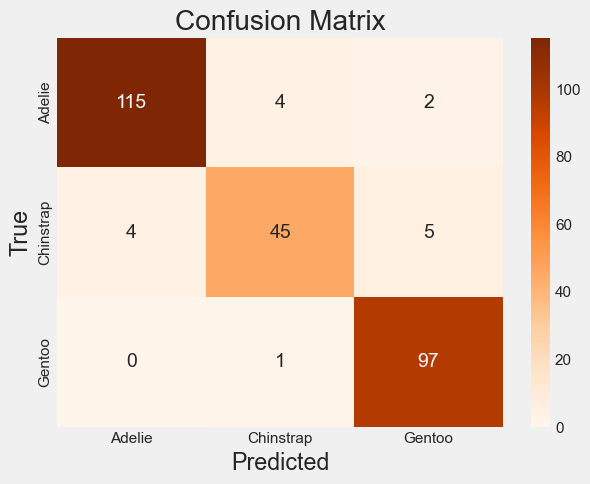

In [86]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5:
        return "Gentoo"
    else:
        if row.bill_length_mm > 43.35:
            return "Chinstrap"
        else:
            return "Adelie"
    

y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97       121
   Chinstrap       0.91      0.93      0.92        54
      Gentoo       1.00      0.99      0.99        98

    accuracy                           0.97       273
   macro avg       0.96      0.96      0.96       273
weighted avg       0.97      0.97      0.97       273



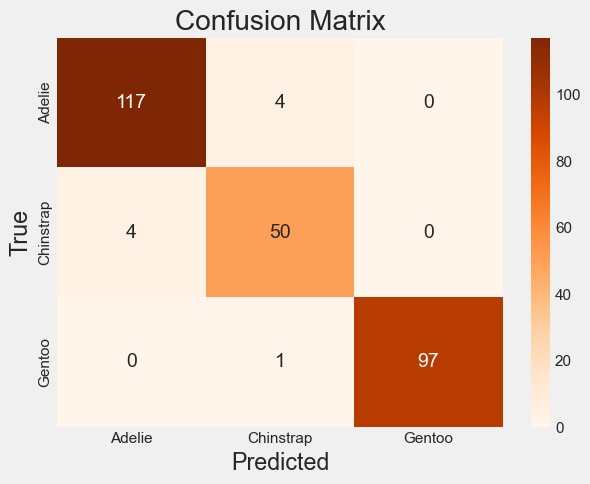

In [87]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5 and row.bill_depth_mm <= 17.55:
        return "Gentoo"
    elif ((row.flipper_length_mm <= 206.5 and row.bill_length_mm > 43.35)
          or (row.flipper_length_mm > 206.5 and row.bill_depth_mm > 17.55 and row.bill_length_mm > 46.55)):
        return "Chinstrap"
    else:
        return "Adelie"
y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

              precision    recall  f1-score   support

      Adelie       0.96      0.99      0.98       121
   Chinstrap       0.98      0.93      0.95        54
      Gentoo       1.00      0.99      0.99        98

    accuracy                           0.98       273
   macro avg       0.98      0.97      0.97       273
weighted avg       0.98      0.98      0.98       273



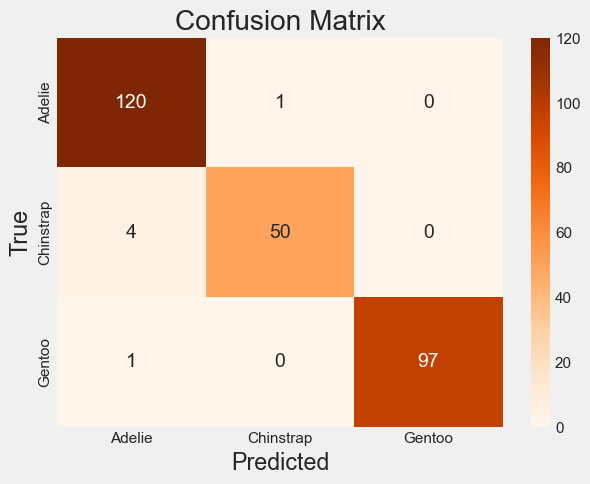

In [88]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5 and row.bill_depth_mm <= 17.55:
        return "Gentoo"
    elif ((row.flipper_length_mm <= 206.5 and row.bill_length_mm > 43.35 and row.island == "Dream")
          or (row.flipper_length_mm > 206.5 and row.bill_depth_mm > 17.55 and row.bill_length_mm > 46.55)):
        return "Chinstrap"
    else:
        return "Adelie"
y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



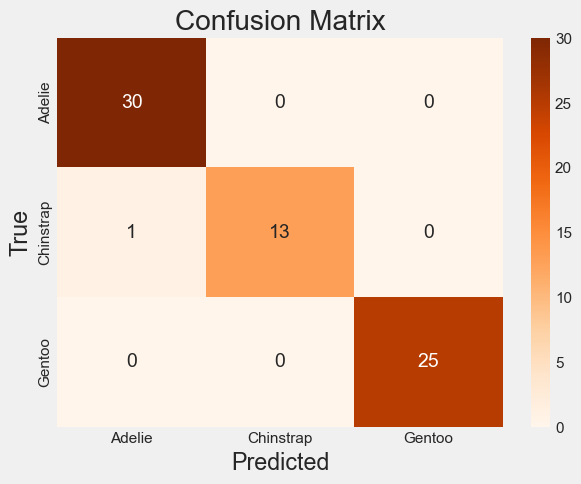

In [89]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5:
        return "Gentoo"
    else:
        if row.bill_length_mm > 43.35:
            return "Chinstrap"
        else:
            return "Adelie"
    

y_pred = X_test.apply(dt_rule, axis=1) 
y_true = y_test

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

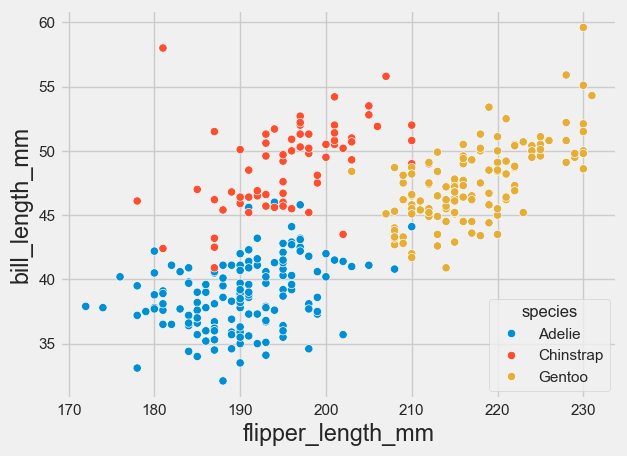

In [90]:
sns.scatterplot(data=df, x='flipper_length_mm', y='bill_length_mm', hue='species');

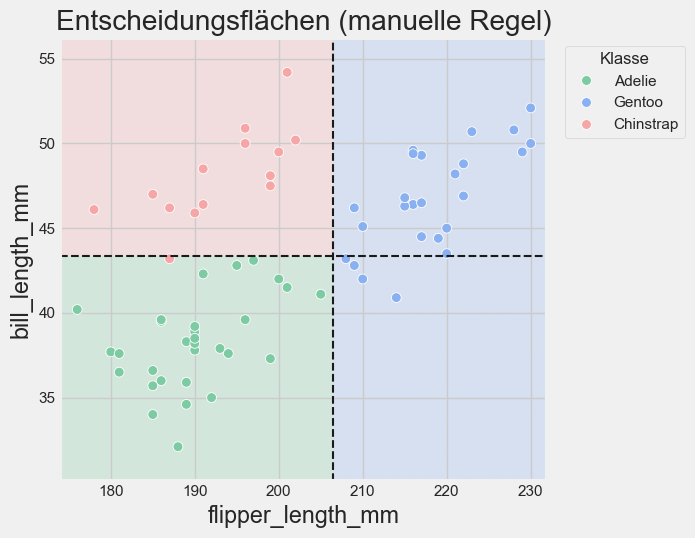

In [ ]:
# Quelle: bib.bib\citep{chatgpt_decision_boundary_plot}

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import ListedColormap

def dt_rule(row):
    if row.flipper_length_mm > 206.5:
        return "Gentoo"
    elif row.bill_length_mm > 43.35:
        return "Chinstrap"
    else:
        return "Adelie"

labels  = ["Adelie", "Chinstrap", "Gentoo"]
palette = {"Adelie": "#7ccba2", "Chinstrap": "#f6a6a6", "Gentoo": "#89b0f0"}

thr_flipper, thr_bill = 206.5, 43.35

x_min, x_max = X_test.flipper_length_mm.min()-2, X_test.flipper_length_mm.max()+2
y_min, y_max = X_test.bill_length_mm.min()-2, X_test.bill_length_mm.max()+2
XX, YY = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

grid = pd.DataFrame({"flipper_length_mm": XX.ravel(),
                     "bill_length_mm": YY.ravel()})
Z = grid.apply(dt_rule, axis=1).values.reshape(XX.shape)

label2idx = {c:i for i,c in enumerate(labels)}
Z_idx = np.vectorize(label2idx.get)(Z)
cmap = ListedColormap([palette[c] for c in labels])

plt.figure(figsize=(7.2,5.6))
plt.imshow(Z_idx, origin="lower", extent=(x_min,x_max,y_min,y_max),
           cmap=cmap, alpha=0.25, aspect="auto", vmin=0, vmax=2)
plt.axvline(thr_flipper, ls="--", c="k", lw=1.5)
plt.axhline(thr_bill,    ls="--", c="k", lw=1.5)

sns.scatterplot(data=X_test.assign(_y=y_true),
                x="flipper_length_mm", y="bill_length_mm",
                hue="_y", palette=palette, edgecolor="white", s=50, lw=0.6)

plt.xlabel("flipper_length_mm"); plt.ylabel("bill_length_mm")
plt.title("Entscheidungsflächen (manuelle Regel)")
plt.legend(title="Klasse", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); 
plt.show()